# Fase 1: Testando a Conexão com a Câmera RTSP
Vamos usar o OpenCV para capturar um frame da câmera e o Matplotlib para exibi-lo aqui no notebook.
É importante entender que o fluxo RTSP é um streaming de vídeo contínuo. Usaremos o `cv2.VideoCapture` para acessar esse stream.

Tentando conectar em: rtsp://admin:@Jeff2712@10.64.0.60:554/
Conexão estabelecida com sucesso!


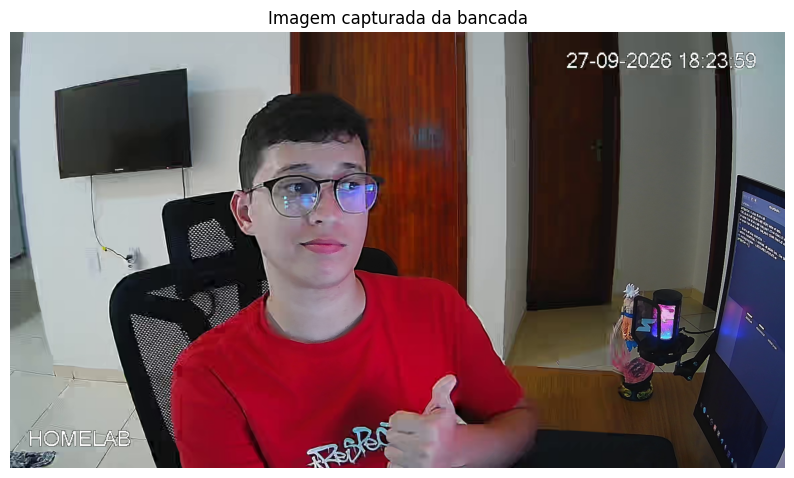

In [2]:
import cv2
import matplotlib.pyplot as plt
import os

# Pegamos a URL da câmera vinda das variáveis de ambiente do docker-compose
RTSP_URL = 'rtsp://admin:@Jeff2712@10.64.0.60:554/'

print(f'Tentando conectar em: {RTSP_URL}')
cap = cv2.VideoCapture(RTSP_URL)

if not cap.isOpened():
    print('Erro: Não foi possível conectar à câmera. Verifique a URL e a rede.')
else:
    print('Conexão estabelecida com sucesso!')
    # Ler apenas um frame
    ret, frame = cap.read()
    if ret:
        # O OpenCV lê as imagens no formato BGR (Azul, Verde, Vermelho).
        # Precisamos converter para RGB para que o Matplotlib exiba as cores corretas.
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10,6))
        plt.imshow(frame_rgb)
        plt.title('Imagem capturada da bancada')
        plt.axis('off')
        plt.show()
    else:
        print('Conectou, mas não conseguiu ler o frame (pacote de vídeo vazio).')
    
    cap.release() # Sempre libere a câmera ao terminar